In [1]:
import sys
sys.path.append("../")

from models.bulge_models import BulgeTemplates
from models.templates import LorimerDiskTemplate
from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist

In [3]:
import healpy as hp
import matplotlib.pyplot as plt
import arviz as az

In [19]:
r_outer = 25
l_max = 0

vary_disk = True
vary_gamma = True
bulge_hybrid = True

ps_cat = "3fgl"
nside = 128

npmodel = NPModel(r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=5000, guide="iaf_mixture", lr=1e-4)

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|██████████| 5000/5000 [05:27<00:00, 15.27it/s, init loss: 28602.6915, avg. loss [4751-5000]: 20098.8063]


In [21]:
posterior = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)

In [22]:
posterior_bulge = {}
for key in list(posterior.keys()):
    if "theta" in key:
        posterior_bulge[key] = posterior[key]
        posterior.pop(key, None)

In [23]:
az.summary(posterior)

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
C,2.642,0.536,1.711,3.625,0.002,0.002,49629.0,48851.0,NaN
S_bub,1.144,0.070,1.017,1.274,0.000,0.000,50739.0,48692.0,NaN
S_dif,11.062,0.126,10.826,11.293,0.001,0.000,50679.0,49794.0,NaN
S_gce,1.113,0.157,0.816,1.406,0.001,0.001,49028.0,48891.0,NaN
S_ics,4.892,0.089,4.738,4.995,0.000,0.000,49311.0,49461.0,NaN
S_iso,0.891,0.104,0.705,1.083,0.000,0.000,49381.0,48267.0,NaN
S_psc,2.092,1.334,0.136,4.442,0.006,0.004,50035.0,49307.0,NaN
Sps_dsk,1.715,0.147,1.449,1.952,0.001,0.000,48957.0,48892.0,NaN
Sps_gce,0.501,0.151,0.250,0.780,0.001,0.000,49067.0,47599.0,NaN
f_bulge_poiss,0.278,0.195,0.016,0.640,0.001,0.001,50144.0,48839.0,NaN


In [24]:
jnp.mean(posterior_bulge['theta_bulge_poiss'], 0)

DeviceArray([0.06123828, 0.0964512 , 0.15326362, 0.32472098, 0.36432592],            dtype=float64)

In [25]:
jnp.mean(posterior_bulge['theta_bulge_ps'], 0)

DeviceArray([0.13549158, 0.11643782, 0.22679053, 0.26631382, 0.25496625],            dtype=float64)

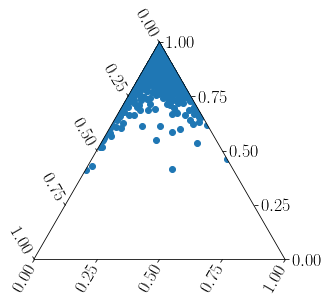

In [26]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)     

In [27]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_ics'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.976,0.034,0.922,1.000,0.0,0.0,50068.0,49747.0,NaN
1,0.012,0.025,0.000,0.049,0.0,0.0,49605.0,49952.0,NaN
2,0.011,0.022,0.000,0.044,0.0,0.0,50539.0,49928.0,NaN


In [28]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_pibrem'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.833,0.060,0.722,0.937,0.0,0.0,48324.0,49296.0,NaN
1,0.158,0.060,0.056,0.274,0.0,0.0,47665.0,47893.0,NaN
2,0.009,0.018,0.000,0.038,0.0,0.0,50452.0,50609.0,NaN
